In [1]:
from loguru import logger
logger.remove()
import sys
logger.add(sys.stderr, level="INFO")

import gc
import numpy as np
import pandas as pd
import xarray as xr
import torch
from pathlib import Path
import itertools

from copy import deepcopy
import matplotlib.colors as mcolors
import colorsys

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(
    context="paper",
    style="ticks",
    palette="Set2",
    rc={
        "figure.dpi": 500, "savefig.dpi": 500,
        "savefig.bbox": "tight",
        "figure.labelsize": "small",
    },
)

from lib.computation.statistics import cluster_correction
from lib.datasets import load_n_subjects, load_target_var, load_dataset
from lib.analyses.loaders import load_significant_times
from lib.analyses._plots import _plot_generalization, _plot_eigenspectrum, _plot_gen_with_p
from bonner.caching import BONNER_CACHING_HOME
from bonner.computation.decomposition import PCA
from bonner.computation.metrics import covariance, pearson_r
from lib.computation.statistics import compute_p
from bonner.datasets.hebart2022_things_behavior import load_embeddings
from lib.datasets.hebart2022_things_behavior import sort_embeddings
from bonner.datasets.gifford2022_things_eeg_2 import load_metadata

# Import helper functions for memory-efficient loading
from lib._notebook_helpers import (
    get_scorer_kwargs,
    load_generalization_data_streaming,
    load_cvpca_generalization_streaming,
    load_cvpca_generalization_at_time_train,
    add_time_markers,
)

In [4]:
# Configuration for time-slice generalization plots
time_train_values = [0.1, 0.2, 0.3]

# EEG paths
eeg_dataset = "things_eeg_2"
eeg_load_dataset_kwargs = "default"
eeg_cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={eeg_dataset}/load_dataset_kwargs={eeg_load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"

# MEG paths
meg_dataset = "things_meg"
meg_load_dataset_kwargs = "from_raw=1.downsample_freq=100.h_freq=100.baseline=(None, 0).rois=op"
meg_cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={meg_dataset}/load_dataset_kwargs={meg_load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"

In [5]:
# Compute peak negative dimensionality time difference distribution
# For each time_train, find time_test with peak neg_cvnsr, then compute |time_train - time_test_peak|

def compute_peak_neg_time_diff(cvpca_path, time_min=-0.05):
    """
    For each time_train, find the time_test with peak negative dimensionality,
    then compute the absolute time difference.
    
    Returns:
        DataFrame with time_train, peak_time_test, and time_diff columns
    """
    cvpca = xr.open_dataset(cvpca_path)
    cvpca = cvpca.sel(time_train=cvpca.time_train >= time_min)
    cvpca = cvpca.sel(time_test=cvpca.time_test >= time_min)
    
    time_train_vals = cvpca.time_train.values
    time_test_vals = cvpca.time_test.values
    
    results = []
    
    for tt in time_train_vals:
        cvpca_slice = cvpca.sel(time_train=tt)
        # Average neg_cvnsr over subjects and splits: shape becomes (time_test,)
        mean_neg_cvnsr = cvpca_slice.gen_neg_cvnsr.mean(dim=["subject", "split"]).values
        
        # Find time_test with peak (max) negative dimensionality
        peak_idx = np.argmax(mean_neg_cvnsr)
        peak_time_test = time_test_vals[peak_idx]
        
        results.append({
            "time_train": tt,
            "peak_time_test": peak_time_test,
            "time_diff": np.abs(tt - peak_time_test),
        })
    
    del cvpca
    gc.collect()
    
    return pd.DataFrame(results)


# Compute for EEG and MEG
eeg_time_diff_df = compute_peak_neg_time_diff(eeg_cvpca_path)
eeg_time_diff_df["dataset"] = "EEG"

In [6]:
eeg_time_diff_df = eeg_time_diff_df[eeg_time_diff_df.time_train >= .1]
eeg_time_diff_df = eeg_time_diff_df[eeg_time_diff_df.time_train <= .4]

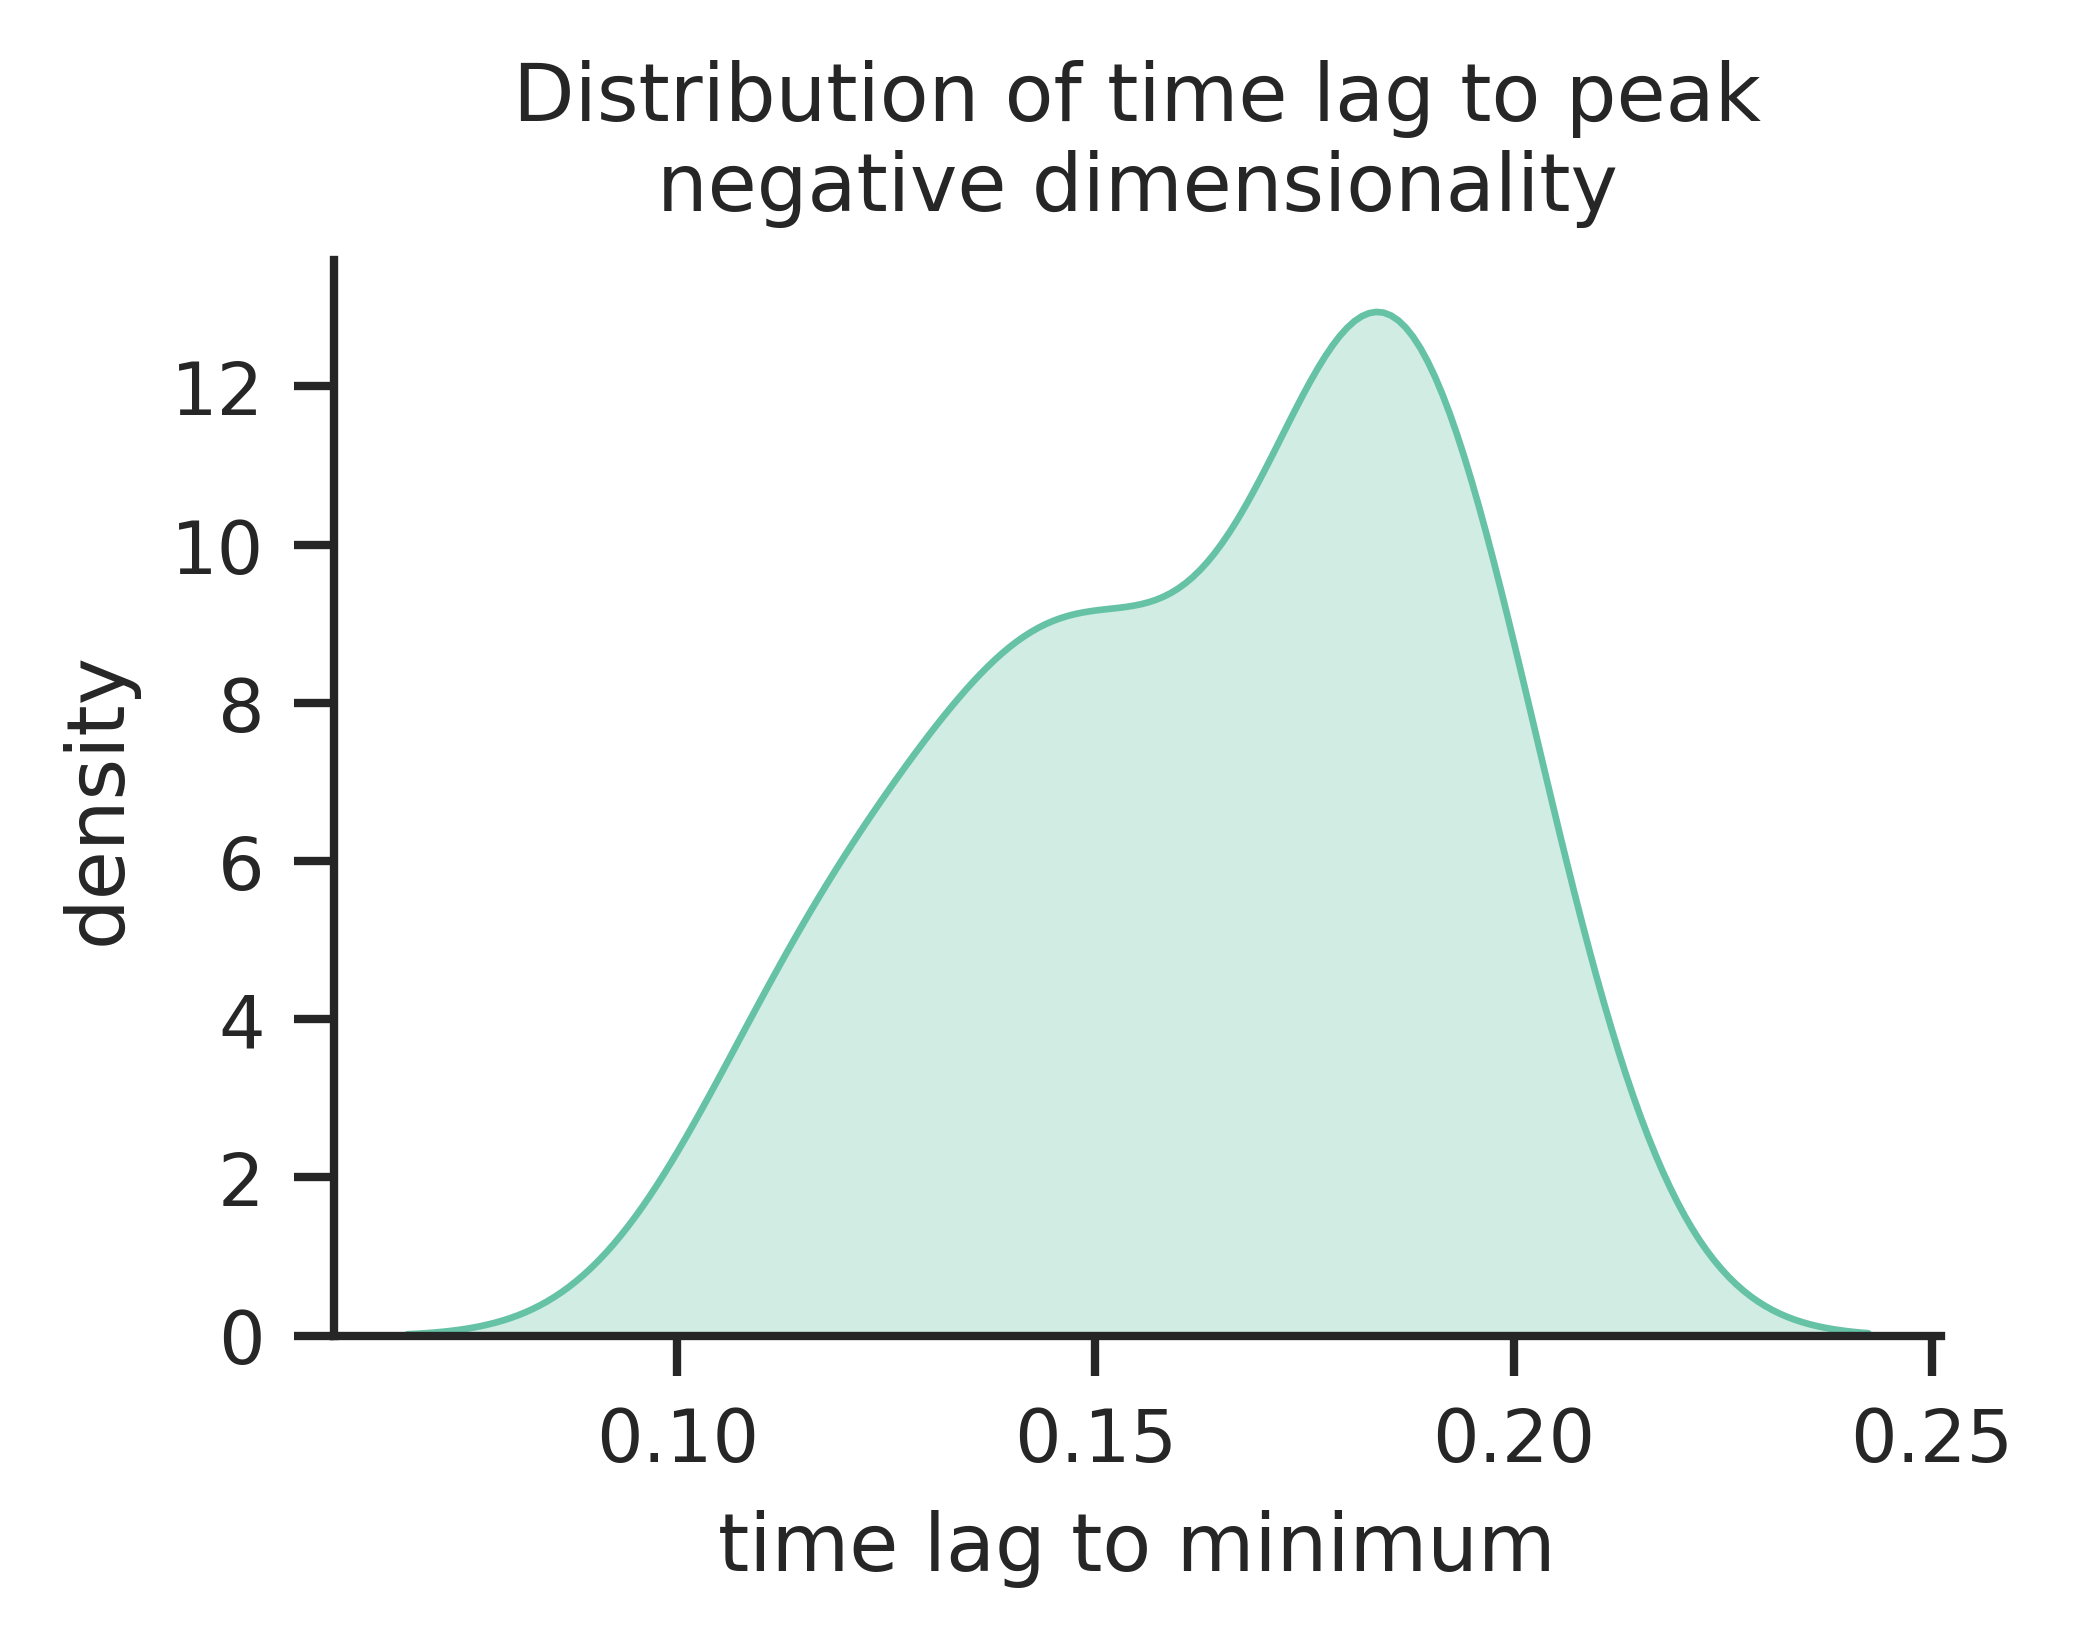

In [11]:
# Plot KDE of time differences for EEG
plt.close()
width_mm = 90
width_inches = width_mm / 25.4
height_inches = width_inches * 0.8
fig, ax = plt.subplots(figsize=(width_inches, height_inches))

sns.kdeplot(data=eeg_time_diff_df, x="time_diff", ax=ax, fill=True, alpha=0.3)

# ax.set(xlabel="|time_train - peak_time_test| (s)", ylabel="density")
ax.set(xlabel="time lag to minimum", ylabel="density")
ax.set_title("Distribution of time lag to peak\nnegative dimensionality")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.legend(fontsize='x-small')

plt.tight_layout()